# Stage 01 Stable Geometry Review

This notebook is a read-only visualization for the stable-geometry Stage 01 results. It focuses on the audit threshold selection, analytic localization quality, stable pilot/full datasets, and the evidence that TDOA-only can still be multi-valued.

In [1]:
from pathlib import Path
import csv
import json
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
for parent in [ROOT] + list(ROOT.parents):
    if (parent / 'python_impl').exists() and (parent / 'README.md').exists():
        ROOT = parent
        break
SRC_DIR = ROOT / 'python_impl' / 'experiments' / 'hypothesis_validation' / '01_source_localization_anechoic_2d' / 'src'
if str(ROOT / 'python_impl') not in sys.path:
    sys.path.insert(0, str(ROOT / 'python_impl'))
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from python_scripts.hypothesis_validation_common import estimate_source_position_from_tdoa, estimate_tdoa_from_gcc_triplet
from stable_geometry_pipeline import find_tdoa_room_solutions, load_geometry_audit_bundle, load_stage01_candidate_prediction_bundle, load_stable_localization_summary

STEP_DIR = ROOT / 'python_impl' / 'experiments' / 'hypothesis_validation' / '01_source_localization_anechoic_2d'
AUDIT_DIR = STEP_DIR / 'results' / 'geometry_stability_audit'
H5_PATH = STEP_DIR / 'data' / 'source_localization_anechoic_2d_l1_stable.h5'
RESULT_DIR = STEP_DIR / 'results' / 'L1_stable'
SAMPLE_INDEX = -1

print('ROOT =', ROOT)
print('AUDIT_DIR =', AUDIT_DIR)
print('H5_PATH =', H5_PATH)
print('RESULT_DIR =', RESULT_DIR)

ROOT = z:\anc\distributed_anc_sim_py
AUDIT_DIR = z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\01_source_localization_anechoic_2d\results\geometry_stability_audit
H5_PATH = z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\01_source_localization_anechoic_2d\data\source_localization_anechoic_2d_l1_stable.h5
RESULT_DIR = z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\01_source_localization_anechoic_2d\results\L1_stable


In [2]:
audit = load_geometry_audit_bundle(AUDIT_DIR)
audit_summary = audit['summary']
selected = audit_summary['selected_thresholds']
selected_window = audit_summary['selected_window_preset']
threshold_df = pd.DataFrame(audit['threshold_grid']).apply(pd.to_numeric, errors='ignore')
sample_df = pd.DataFrame(audit['sample_metrics']).apply(pd.to_numeric, errors='ignore')
display(pd.Series(selected, name='selected_thresholds'))
baseline_table = pd.DataFrame([
    {
        'mode': 'raw_W1_gcc_phat',
        'iid_median_m': audit_summary['runs']['W1']['gcc_phat_iid_test']['median_m'],
        'iid_p90_m': audit_summary['runs']['W1']['gcc_phat_iid_test']['p90_m'],
        'geom_median_m': audit_summary['runs']['W1']['gcc_phat_geom_test']['median_m'],
        'geom_p90_m': audit_summary['runs']['W1']['gcc_phat_geom_test']['p90_m'],
    },
    {
        'mode': 'stable_filtered_gcc_phat',
        'iid_median_m': selected['gcc_phat_iid_test_median_m'],
        'iid_p90_m': selected['gcc_phat_iid_test_p90_m'],
        'geom_median_m': selected['gcc_phat_geom_test_median_m'],
        'geom_p90_m': selected['gcc_phat_geom_test_p90_m'],
    },
])
display(baseline_table)

C:\Windows\Temp\ipykernel_24944\1935390514.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  threshold_df = pd.DataFrame(audit['threshold_grid']).apply(pd.to_numeric, errors='ignore')
C:\Windows\Temp\ipykernel_24944\1935390514.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  sample_df = pd.DataFrame(audit['sample_metrics']).apply(pd.to_numeric, errors='ignore')


area_min                            0.1
cond_max                           40.0
retention_overall               0.85417
retention_iid_test             0.851867
retention_geom_test            0.853545
gcc_phat_iid_test_median_m      0.00569
gcc_phat_iid_test_p90_m        0.082587
gcc_phat_geom_test_median_m     0.00567
gcc_phat_geom_test_p90_m       0.079128
oracle_iid_test_median_m            0.0
oracle_iid_test_p90_m          0.000001
oracle_geom_test_median_m           0.0
oracle_geom_test_p90_m         0.000001
passed                             True
Name: selected_thresholds, dtype: object

,mode,iid_median_m,iid_p90_m,geom_median_m,geom_p90_m
0,raw_W1_gcc_phat,0.007413,0.259356,0.00733,0.264530
1,stable_filtered_gcc_phat,0.005690,0.082587,0.00567,0.079128


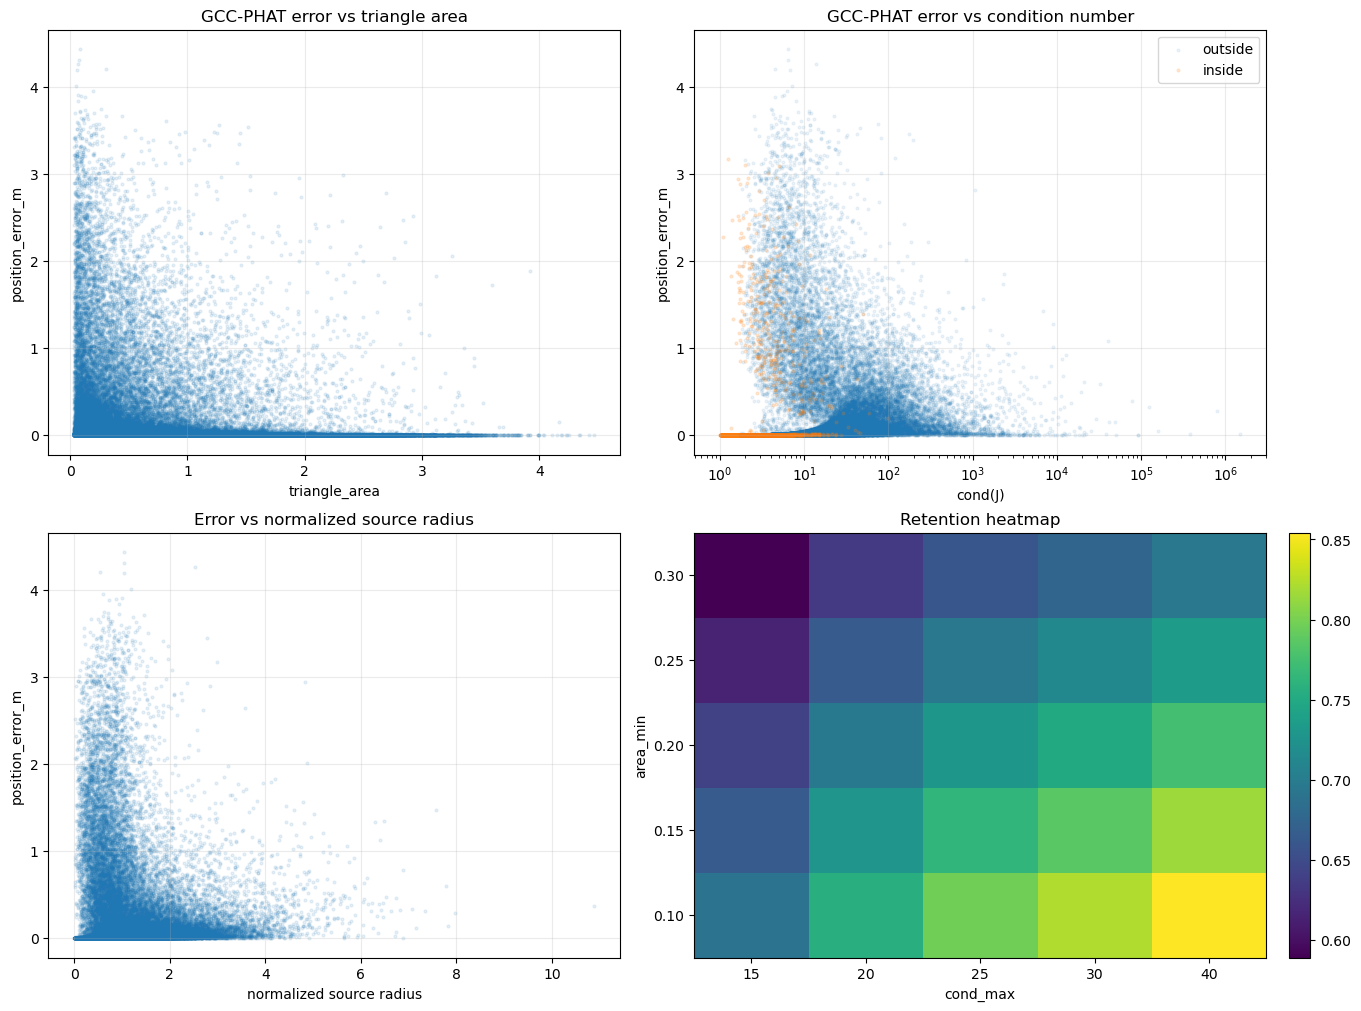

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.0), constrained_layout=True)

axes[0, 0].scatter(sample_df['triangle_area'], sample_df['gcc_phat_position_error_m'], s=4, alpha=0.10)
axes[0, 0].set_xlabel('triangle_area')
axes[0, 0].set_ylabel('position_error_m')
axes[0, 0].set_title('GCC-PHAT error vs triangle area')
axes[0, 0].grid(True, alpha=0.25)

inside = sample_df['inside_convex_hull'].to_numpy() > 0.5
axes[0, 1].scatter(sample_df.loc[~inside, 'jacobian_condition'], sample_df.loc[~inside, 'gcc_phat_position_error_m'], s=4, alpha=0.08, label='outside')
axes[0, 1].scatter(sample_df.loc[inside, 'jacobian_condition'], sample_df.loc[inside, 'gcc_phat_position_error_m'], s=4, alpha=0.16, label='inside')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel('cond(J)')
axes[0, 1].set_ylabel('position_error_m')
axes[0, 1].set_title('GCC-PHAT error vs condition number')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.25)

axes[1, 0].scatter(sample_df['centroid_source_dist_norm'], sample_df['gcc_phat_position_error_m'], s=4, alpha=0.10)
axes[1, 0].set_xlabel('normalized source radius')
axes[1, 0].set_ylabel('position_error_m')
axes[1, 0].set_title('Error vs normalized source radius')
axes[1, 0].grid(True, alpha=0.25)

pivot = threshold_df.pivot(index='area_min', columns='cond_max', values='retention_overall')
heat = axes[1, 1].imshow(pivot.to_numpy(), origin='lower', aspect='auto')
axes[1, 1].set_xticks(np.arange(pivot.shape[1]), labels=[str(int(v)) for v in pivot.columns])
axes[1, 1].set_yticks(np.arange(pivot.shape[0]), labels=[f'{v:.2f}' for v in pivot.index])
axes[1, 1].set_xlabel('cond_max')
axes[1, 1].set_ylabel('area_min')
axes[1, 1].set_title('Retention heatmap')
fig.colorbar(heat, ax=axes[1, 1], fraction=0.046, pad=0.04)
plt.show()

In [4]:
stable_summary = load_stable_localization_summary(RESULT_DIR)
with h5py.File(H5_PATH, 'r') as h5:
    ref_positions = np.asarray(h5['raw/ref_positions'], dtype=np.float32)
    source_position = np.asarray(h5['raw/source_position'], dtype=np.float32)
    gcc_phat = np.asarray(h5['raw/gcc_phat'], dtype=np.float32)
    true_tdoa = np.asarray(h5['raw/true_tdoa'], dtype=np.float32)
    geom_metrics = np.asarray(h5['raw/geometry_metrics'], dtype=np.float32)
    metric_names = json.loads(h5.attrs['geometry_metric_names_json'])
    cfg = json.loads(h5.attrs['config_json'])
geom_name_to_idx = {name: i for i, name in enumerate(metric_names)}
comparison_rows = [
    {
        'method': 'oracle_from_true_tdoa',
        'iid_median_m': selected['oracle_iid_test_median_m'],
        'iid_p90_m': selected['oracle_iid_test_p90_m'],
        'geom_median_m': selected['oracle_geom_test_median_m'],
        'geom_p90_m': selected['oracle_geom_test_p90_m'],
    },
    {
        'method': 'plain_gcc',
        'iid_median_m': stable_summary['analytic_plain_gcc']['iid_test']['median_m'],
        'iid_p90_m': stable_summary['analytic_plain_gcc']['iid_test']['p90_m'],
        'geom_median_m': stable_summary['analytic_plain_gcc']['geom_test']['median_m'],
        'geom_p90_m': stable_summary['analytic_plain_gcc']['geom_test']['p90_m'],
    },
    {
        'method': 'gcc_phat',
        'iid_median_m': stable_summary['analytic_gcc_phat']['iid_test']['median_m'],
        'iid_p90_m': stable_summary['analytic_gcc_phat']['iid_test']['p90_m'],
        'geom_median_m': stable_summary['analytic_gcc_phat']['geom_test']['median_m'],
        'geom_p90_m': stable_summary['analytic_gcc_phat']['geom_test']['p90_m'],
    },
]
display(pd.DataFrame(comparison_rows))
display(pd.DataFrame(geom_metrics, columns=metric_names).describe().T[['mean', 'std', 'min', 'max']])

,method,iid_median_m,iid_p90_m,geom_median_m,geom_p90_m
0,oracle_from_true_tdoa,0.000000,0.000001,2.980232e-08,0.000001
1,plain_gcc,0.005377,0.080165,5.210500e-03,0.069928
2,gcc_phat,0.005917,0.085404,5.470394e-03,0.072132


,mean,std,min,max
triangle_area,0.873098,0.650436,0.100130,4.111135
edge_len_min,1.059966,0.470126,0.250636,3.013152
edge_len_mid,1.802913,0.533944,0.489088,3.563743
edge_len_max,2.274859,0.604438,0.547433,4.098139
edge_len_ratio,2.550726,1.400347,1.009405,13.404249
centroid_source_dist,1.393803,0.602944,0.034192,3.530856
centroid_source_dist_norm,0.892220,0.518767,0.018474,4.235750
inside_convex_hull,0.077333,0.267144,0.000000,1.000000
min_source_ref_dist,1.059655,0.517002,0.300086,3.331331
max_source_ref_dist,2.322591,0.612205,0.592681,4.269303


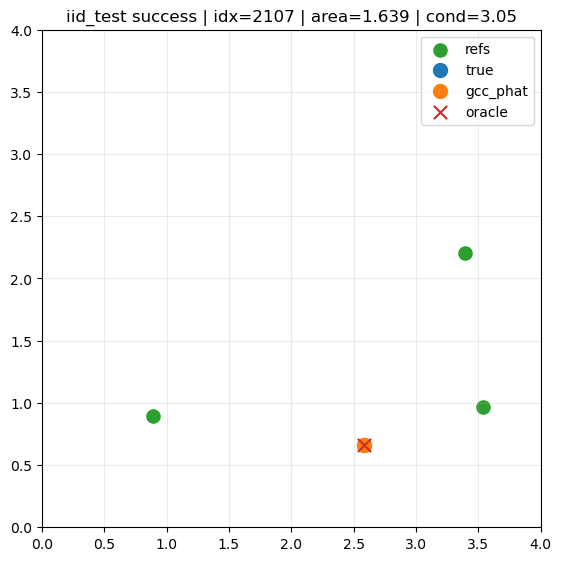

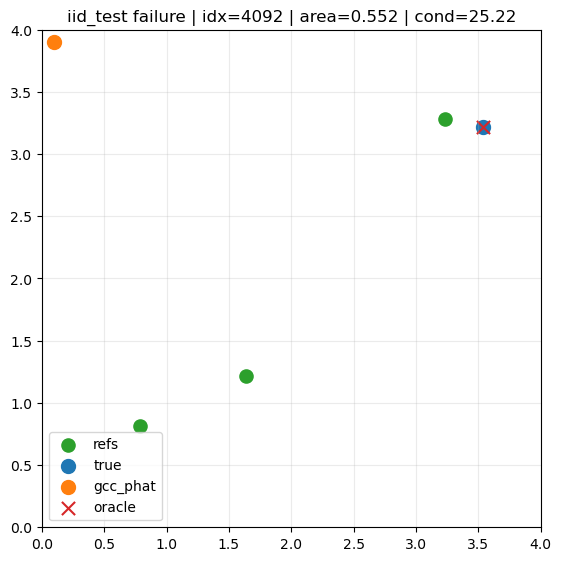

In [5]:
analytic_rows = list(csv.DictReader((RESULT_DIR / 'analytic_sample_errors.csv').open('r', encoding='utf-8', newline='')))
analytic_df = pd.DataFrame(analytic_rows)
analytic_df['sample_index'] = analytic_df['sample_index'].astype(int)
analytic_df['position_error_m'] = analytic_df['position_error_m'].astype(float)

def _analytic_pred(sample_index: int, method: str):
    if method == 'oracle':
        lag = true_tdoa[sample_index]
    elif method == 'gcc_phat':
        lag = estimate_tdoa_from_gcc_triplet(gcc_phat[sample_index])
    else:
        raise KeyError(method)
    return estimate_source_position_from_tdoa(lag, ref_positions[sample_index], tuple(cfg['plane_room_size']), int(cfg['fs']), float(cfg['c']))

def plot_localization_sample(sample_index: int, title: str):
    gcc_pred = _analytic_pred(sample_index, 'gcc_phat')
    oracle_pred = _analytic_pred(sample_index, 'oracle')
    tri = ref_positions[sample_index]
    src = source_position[sample_index]
    area = geom_metrics[sample_index, geom_name_to_idx['triangle_area']]
    cond = geom_metrics[sample_index, geom_name_to_idx['jacobian_condition']]
    fig, ax = plt.subplots(figsize=(5.5, 5.5), constrained_layout=True)
    ax.scatter(tri[:, 0], tri[:, 1], s=90, color='tab:green', label='refs')
    ax.scatter(src[0], src[1], s=100, color='tab:blue', label='true')
    ax.scatter(gcc_pred[0], gcc_pred[1], s=100, color='tab:orange', label='gcc_phat')
    ax.scatter(oracle_pred[0], oracle_pred[1], s=90, color='tab:red', marker='x', label='oracle')
    ax.set_xlim(0.0, cfg['plane_room_size'][0])
    ax.set_ylim(0.0, cfg['plane_room_size'][1])
    ax.set_title(f"{title} | idx={sample_index} | area={area:.3f} | cond={cond:.2f}")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

subset = analytic_df[(analytic_df['method'] == 'gcc_phat') & (analytic_df['split'] == 'iid_test')].sort_values('position_error_m')
success_idx = int(subset.iloc[0]['sample_index'])
failure_idx = int(subset.iloc[-1]['sample_index'])
plot_localization_sample(success_idx, 'iid_test success')
plot_localization_sample(failure_idx, 'iid_test failure')

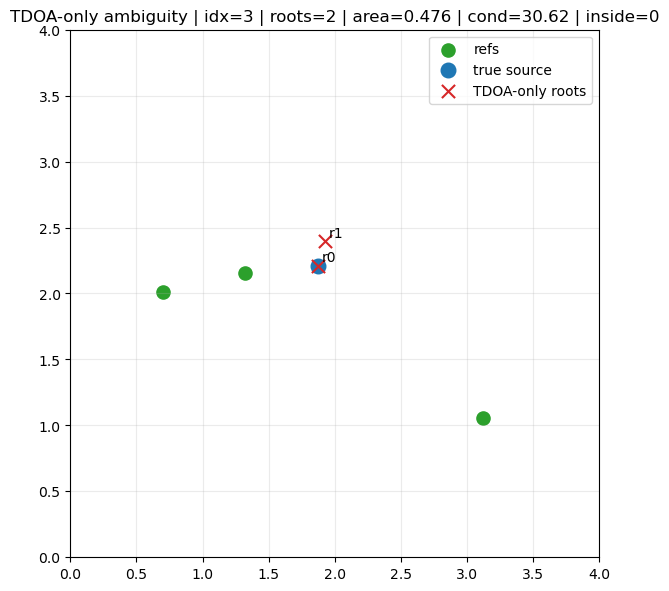

In [6]:
sample_index = int(SAMPLE_INDEX)
if sample_index < 0:
    sample_index = -1
    for idx in range(min(512, len(true_tdoa))):
        sols = find_tdoa_room_solutions(true_tdoa[idx], ref_positions[idx], tuple(cfg['plane_room_size']), int(cfg['fs']), float(cfg['c']))
        if sols.shape[0] > 1:
            sample_index = idx
            break
    if sample_index < 0:
        raise RuntimeError('No multi-solution sample found in the scanned subset.')
solutions = find_tdoa_room_solutions(true_tdoa[sample_index], ref_positions[sample_index], tuple(cfg['plane_room_size']), int(cfg['fs']), float(cfg['c']))
tri = ref_positions[sample_index]
src = source_position[sample_index]
fig, ax = plt.subplots(figsize=(5.8, 5.8), constrained_layout=True)
ax.scatter(tri[:, 0], tri[:, 1], s=90, color='tab:green', label='refs')
ax.scatter(src[0], src[1], s=110, color='tab:blue', label='true source')
if len(solutions):
    ax.scatter(solutions[:, 0], solutions[:, 1], s=90, color='tab:red', marker='x', label='TDOA-only roots')
for idx, sol in enumerate(solutions):
    ax.text(sol[0] + 0.03, sol[1] + 0.03, f'r{idx}', fontsize=10)
area = geom_metrics[sample_index, geom_name_to_idx['triangle_area']]
cond = geom_metrics[sample_index, geom_name_to_idx['jacobian_condition']]
inside = geom_metrics[sample_index, geom_name_to_idx['inside_convex_hull']]
ax.set_xlim(0.0, cfg['plane_room_size'][0])
ax.set_ylim(0.0, cfg['plane_room_size'][1])
ax.grid(True, alpha=0.25)
ax.legend()
ax.set_title(f"TDOA-only ambiguity | idx={sample_index} | roots={len(solutions)} | area={area:.3f} | cond={cond:.2f} | inside={inside:.0f}")
plt.show()

In [7]:
summary_path = RESULT_DIR / 'summary.json'
if summary_path.exists():
    summary = load_stable_localization_summary(RESULT_DIR)
    learned = summary.get('learned', {})
    if learned:
        learned_rows = []
        for key, value in learned.items():
            learned_rows.append({
                'key': key,
                'median_m': value['median_m'],
                'p90_m': value['p90_m'],
                'mean_m': value['mean_m'],
                'max_m': value['max_m'],
            })
        learned_df = pd.DataFrame(learned_rows).sort_values(['p90_m', 'median_m'])
        display(learned_df)
    else:
        print('No learned-model metrics found in RESULT_DIR/summary.json yet.')
else:
    print('RESULT_DIR/summary.json does not exist yet.')

,key,median_m,p90_m,mean_m,max_m
4,geom_tdoa,0.536185,1.191484,0.635196,2.298774
0,iid_tdoa,0.543164,1.227366,0.641998,2.725844
5,geom_tdoa_resmlp,0.707918,1.408558,0.778482,2.946711
1,iid_tdoa_resmlp,0.746866,1.455777,0.813259,2.455558
3,iid_gcc_cov,1.291483,2.107969,1.317084,3.583834
7,geom_gcc_cov,1.285465,2.132771,1.316840,4.213172
6,geom_gcc,1.319143,2.150383,1.337199,5.435479
2,iid_gcc,1.299786,2.155293,1.339704,3.155388


In [8]:
summary_path = RESULT_DIR / 'summary.json'
if summary_path.exists():
    summary = load_stable_localization_summary(RESULT_DIR)
    if summary.get('learned'):
        pred_bundle = load_stage01_candidate_prediction_bundle(H5_PATH, RESULT_DIR, model_key=None, device='auto')
        pred = pred_bundle['pred_global']
        true = pred_bundle['true_global']
        err = pred_bundle['error_m']
        sample = np.random.default_rng(0).choice(np.arange(pred.shape[0]), size=min(300, pred.shape[0]), replace=False)
        fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5), constrained_layout=True)
        axes[0].scatter(true[sample, 0], true[sample, 1], s=18, alpha=0.35, label='true')
        axes[0].scatter(pred[sample, 0], pred[sample, 1], s=18, alpha=0.35, label='pred')
        axes[0].set_xlim(0.0, cfg['plane_room_size'][0])
        axes[0].set_ylim(0.0, cfg['plane_room_size'][1])
        axes[0].set_title(f"Best learned candidate: {pred_bundle['model_key']}")
        axes[0].grid(True, alpha=0.25)
        axes[0].legend()
        axes[1].hist(err, bins=50, color='tab:orange', alpha=0.85)
        axes[1].set_title('Learned candidate error histogram')
        axes[1].set_xlabel('error_m')
        axes[1].set_ylabel('count')
        axes[1].grid(True, alpha=0.25)
        plt.show()
    else:
        print('No learned candidate metrics available in RESULT_DIR.')
else:
    print('RESULT_DIR/summary.json does not exist yet.')

KeyError: 'candidate_id'